In [2]:
import pandas as pd
import numpy as np
import random
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
file_path = "spam.csv"

df = pd.read_csv(
    file_path,
    encoding="latin-1"
)

# Keep only required columns
df = df[["v1", "v2"]]

# Rename columns
df.columns = ["label", "text"]

# Remove missing values
df = df.dropna()

# Remove duplicate messages
df = df.drop_duplicates()

print("Dataset shape:", df.shape)

print("\nClass distribution:")
print(df["label"].value_counts())

Dataset shape: (5169, 2)

Class distribution:
label
ham     4516
spam     653
Name: count, dtype: int64


In [6]:
df["label_id"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print("\nEncoded class distribution:")
print(df["label_id"].value_counts())


# ============================================================
# 4. MAJORITY CLASS BASELINE
# ============================================================

majority_class = df["label_id"].mode()[0]

baseline_accuracy = (
    df["label_id"] == majority_class
).mean()

print(
    "\nMajority Class Baseline:",
    f"{baseline_accuracy * 100:.2f}%"
)


Encoded class distribution:
label_id
0    4516
1     653
Name: count, dtype: int64

Majority Class Baseline: 87.37%


In [7]:
X = df["text"]
y = df["label_id"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 4135
Testing samples: 1034


In [8]:
MAX_WORDS = 10000
MAX_LEN = 80

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

# IMPORTANT:
# Vocabulary is created using training data only
tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(
    X_train
)

X_test_sequences = tokenizer.texts_to_sequences(
    X_test
)

In [9]:
X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("\nTraining data shape:", X_train_padded.shape)
print("Testing data shape:", X_test_padded.shape)


Training data shape: (4135, 80)
Testing data shape: (1034, 80)


In [10]:
y_train = np.array(y_train)
y_test = np.array(y_test)

In [11]:
model = Sequential([

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=64,
        input_length=MAX_LEN
    ),

    LSTM(
        64,
        return_sequences=False
    ),

    Dropout(0.3),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [14]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_padded,
    y_train,
    validation_split=0.20,
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.8531 - loss: 0.4837 - val_accuracy: 0.8791 - val_loss: 0.3695
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8706 - loss: 0.3881 - val_accuracy: 0.8791 - val_loss: 0.3693
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8706 - loss: 0.3888 - val_accuracy: 0.8791 - val_loss: 0.3693
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8706 - loss: 0.3899 - val_accuracy: 0.8791 - val_loss: 0.3691
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8706 - loss: 0.3914 - val_accuracy: 0.8791 - val_loss: 0.3694
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8706 - loss: 0.3890 - val_accuracy: 0.8791 - val_loss: 0.3691


In [16]:
test_loss, test_accuracy = model.evaluate(
    X_test_padded,
    y_test,
    verbose=0
)

print("FINAL TEST RESULTS")

print(
    f"Majority Baseline: "
    f"{baseline_accuracy * 100:.2f}%"
)

print(
    f"LSTM Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Improvement over Baseline: "
    f"{(test_accuracy - baseline_accuracy) * 100:.2f} "
    f"percentage points"
)

FINAL TEST RESULTS
Majority Baseline: 87.37%
LSTM Test Accuracy: 87.33%
Improvement over Baseline: -0.04 percentage points


In [17]:
probabilities = model.predict(
    X_test_padded,
    verbose=0
)

predictions = (
    probabilities >= 0.5
).astype(int).flatten()

In [18]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "\nAccuracy using sklearn:",
    f"{accuracy * 100:.2f}%"
)


Accuracy using sklearn: 87.33%


In [19]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        predictions,
        target_names=[
            "Ham",
            "Spam"
        ]
    )
)


Classification Report:
              precision    recall  f1-score   support

         Ham       0.87      1.00      0.93       903
        Spam       0.00      0.00      0.00       131

    accuracy                           0.87      1034
   macro avg       0.44      0.50      0.47      1034
weighted avg       0.76      0.87      0.81      1034



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
cm = confusion_matrix(
    y_test,
    predictions
)

print("\nConfusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negative:", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive:", tp)


Confusion Matrix:
[[903   0]
 [131   0]]

True Negative: 903
False Positive: 0
False Negative: 131
True Positive: 0


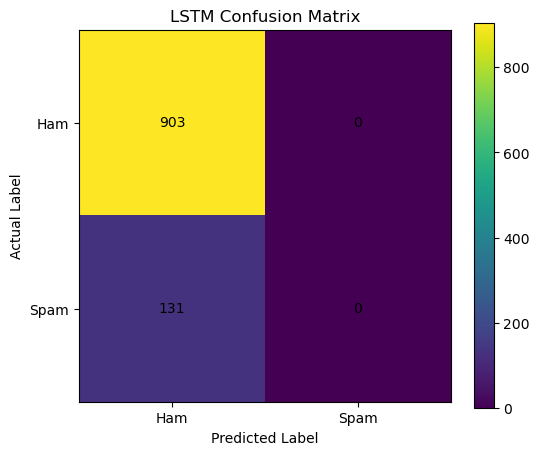

In [21]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Ham", "Spam"]
)

plt.yticks(
    [0, 1],
    ["Ham", "Spam"]
)
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

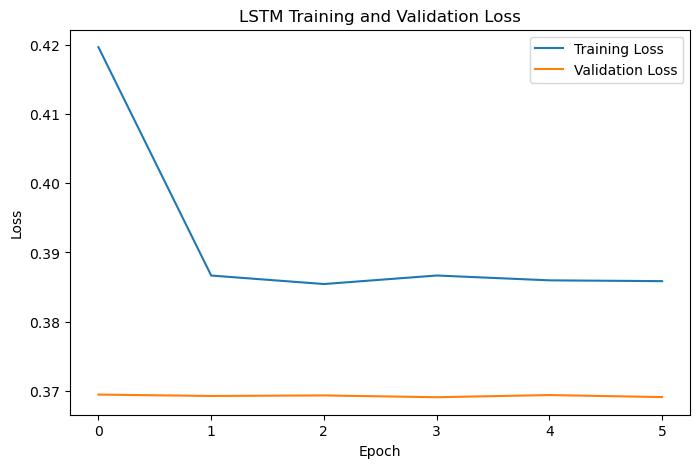

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()


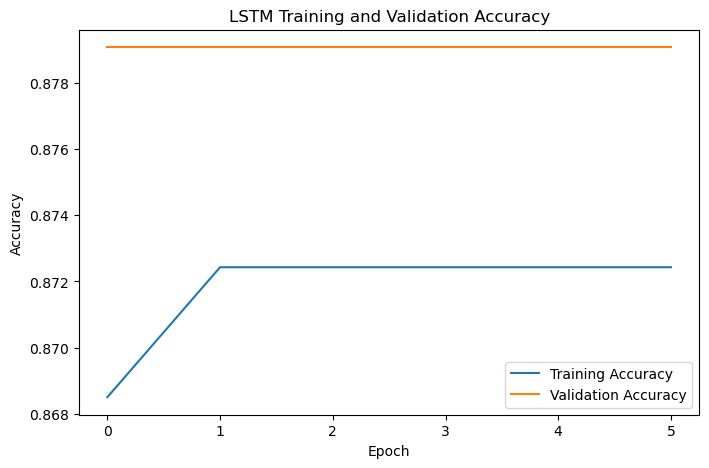

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()


In [24]:
results = pd.DataFrame({
    "Message": X_test.values,
    "Actual": y_test,
    "Predicted": predictions
})

results["Actual"] = results["Actual"].map({
    0: "Ham",
    1: "Spam"
})

results["Predicted"] = results["Predicted"].map({
    0: "Ham",
    1: "Spam"
})

print("\nSample Predictions:")
print(
    results.head(20).to_string(index=False)
)


Sample Predictions:
                                                                                                                                                        Message Actual Predicted
Good morning, my Love ... I go to sleep now and wish you a great day full of feeling better and opportunity ... You are my last thought babe, I LOVE YOU *kiss*    Ham       Ham
                                                                                                                         And how you will do that, princess? :)    Ham       Ham
                                                                                                                 Nope. Meanwhile she talk say make i greet you.    Ham       Ham
                                                                                                 Designation is software developer and may be she get chennai:)    Ham       Ham
                                                                                              

In [25]:
print("SUMMARY")


print(
    "Total Dataset:",
    len(df)
)

print(
    "Training Samples:",
    len(X_train)
)

print(
    "Test Samples:",
    len(X_test)
)

print(
    "Vocabulary Size:",
    min(
        MAX_WORDS,
        len(tokenizer.word_index) + 1
    )
)
print(
    f"Majority Baseline: "
    f"{baseline_accuracy * 100:.2f}%"
)

print(
    f"LSTM Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Improvement: "
    f"{(test_accuracy - baseline_accuracy) * 100:.2f} "
    f"percentage points"
)

SUMMARY
Total Dataset: 5169
Training Samples: 4135
Test Samples: 1034
Vocabulary Size: 7817
Majority Baseline: 87.37%
LSTM Test Accuracy: 87.33%
Improvement: -0.04 percentage points
